# Artificial Neural Network (ANN) 

# *Hotel Booking Status Prediction*

### 1. Import libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-test split
from sklearn.model_selection import train_test_split

# Neural Network (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

### 2.Load the Data

In [3]:
df = pd.read_csv(r"Hotel Reservations.csv")

In [4]:
# Shape of Dataset
df.shape

(36275, 19)

In [5]:
# Dataset
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

### 3. Explore the target variable

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


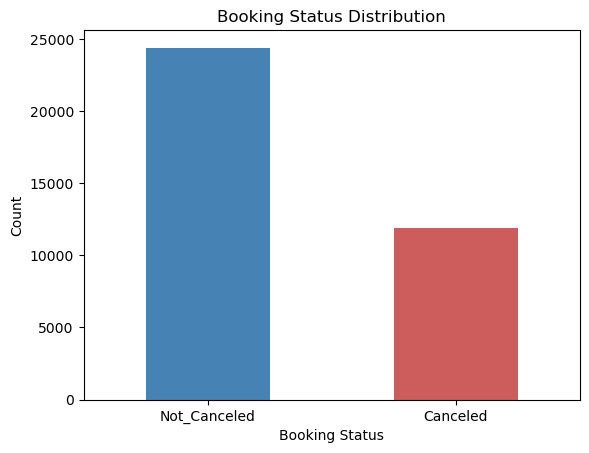

In [7]:
print(df['booking_status'].value_counts())

df['booking_status'].value_counts().plot(kind='bar', color=['steelblue','indianred'])
plt.title('Booking Status Distribution')
plt.ylabel('Count')
plt.xlabel('Booking Status')
plt.xticks(rotation=0)  
plt.show()

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


### 4. Feature engineering

In [9]:
df = df.drop(columns=['Booking_ID'])

df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']
df['total_guests'] = df['no_of_adults'] + df['no_of_children']

df[['no_of_weekend_nights','no_of_week_nights','total_nights',
    'no_of_adults','no_of_children','total_guests']].head()

,no_of_weekend_nights,no_of_week_nights,total_nights,no_of_adults,no_of_children,total_guests
0,1,2,3,2,0,2
1,2,3,5,2,0,2
2,2,1,3,1,0,1
3,0,2,2,2,0,2
4,1,1,2,2,0,2


### 5. Encode the target and features

In [10]:
# Features
X = df.drop(columns=['booking_status'])
# Target
y = df['booking_status']

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:\n", num_cols.tolist())
print("\nCategorical Columns:\n", cat_cols.tolist())

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), cat_cols)
    ]
)

Numerical Columns:
 ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'total_nights', 'total_guests']

Categorical Columns:
 ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

### 6. Train-Test Split

In [13]:
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(25392, 19)
(25392,)
(10883, 19)
(10883,)


### 7. Scale the Features

In [14]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(25392, 19)
(10883, 19)


### 8. Build the ANN Model

In [15]:
model = Sequential()
model.add(Dense(units=256,activation='relu',input_shape=(X.shape[1],)))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(units= 128, activation="relu"))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(units= 64, activation="relu"))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(units=1,activation="sigmoid"))

In [16]:
# Model Architecture Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 47,233 (184.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
# Compiling the Neural Network Model
model.compile(optimizer = "adam", loss="binary_crossentropy", metrics =['accuracy'])

In [18]:
# Eaarly stopping
early_stop =  EarlyStopping(patience = 10,restore_best_weights=True, monitor='val_loss')

### 9. Train the model

In [19]:
# Training the Neural Network Model
history = model.fit(X_train, y_train,validation_split=0.2,
                    epochs=100,callbacks=[early_stop],
                    verbose=1)

Epoch 1/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7540 - loss: 0.5150 - val_accuracy: 0.8137 - val_loss: 0.4122
Epoch 2/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7942 - loss: 0.4440 - val_accuracy: 0.8200 - val_loss: 0.3980
Epoch 3/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8038 - loss: 0.4271 - val_accuracy: 0.8269 - val_loss: 0.3928
Epoch 4/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8085 - loss: 0.4212 - val_accuracy: 0.8362 - val_loss: 0.3796
Epoch 5/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8169 - loss: 0.4088 - val_accuracy: 0.8285 - val_loss: 0.3810
Epoch 6/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8169 - loss: 0.4032 - val_accuracy: 0.8330 - val_loss: 0.3753
Epoch 7/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8213 - loss: 0.3985 - val_accuracy: 0.8423 - val_loss: 0.3688
Epoch 8/100
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8252 - loss: 0.3965 - va

In [20]:
# Model Performance Evaluation
model.evaluate(X_test,y_test)

341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8644 - loss: 0.3102


[0.31019699573516846, 0.864375650882721]

In [21]:
# Model Predictions
output = model.predict(X_test)

341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [22]:
# Converting Prediction Probabilities to Class Labels
output.argmax(axis=1) #index of max element

array([0, 0, 0, ..., 0, 0, 0], shape=(10883,))

In [23]:
output

array([[0.99997187],
       [0.9062457 ],
       [0.94954914],
       ...,
       [0.93620414],
       [0.05065144],
       [0.00418471]], shape=(10883, 1), dtype=float32)

In [24]:
history

### 10. Visualize training history

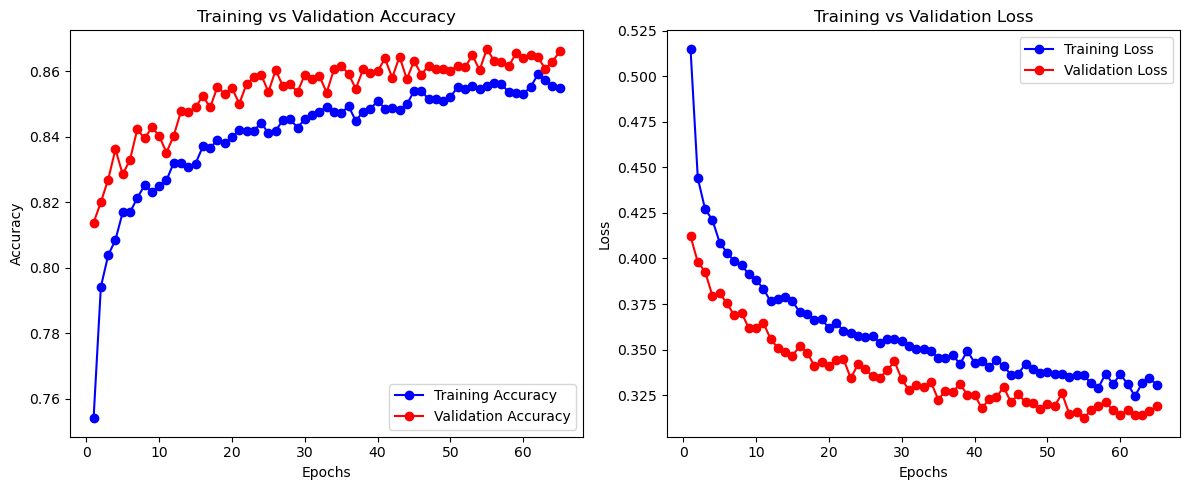

In [25]:
# Training and Validation Performance Visualization
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

# Number of epochs
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 11. Evaluate on the test set

In [26]:
# Model Evaluation
y_prob = model.predict(X_test).ravel()   # predicted probability of cancellation
y_pred = (y_prob >= 0.5).astype(int)        # convert probability to class label

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not_Canceled', 'Canceled']))

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Test Accuracy : 0.8644
Test ROC-AUC  : 0.9310

              precision    recall  f1-score   support

Not_Canceled       0.83      0.75      0.78      3607
    Canceled       0.88      0.92      0.90      7276

    accuracy                           0.86     10883
   macro avg       0.85      0.83      0.84     10883
weighted avg       0.86      0.86      0.86     10883



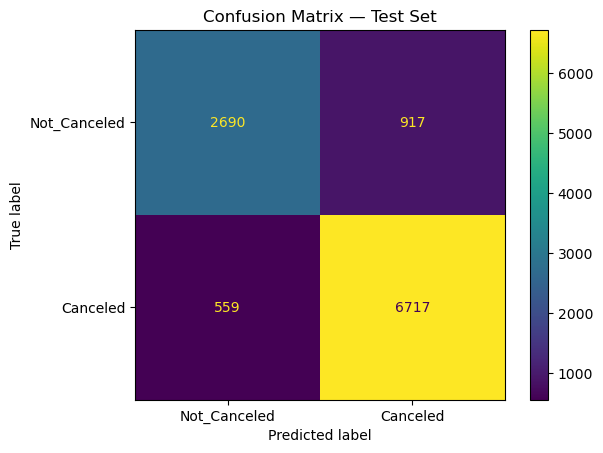

In [27]:
# confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,display_labels=['Not_Canceled', 'Canceled'])
plt.title('Confusion Matrix — Test Set')
plt.show()

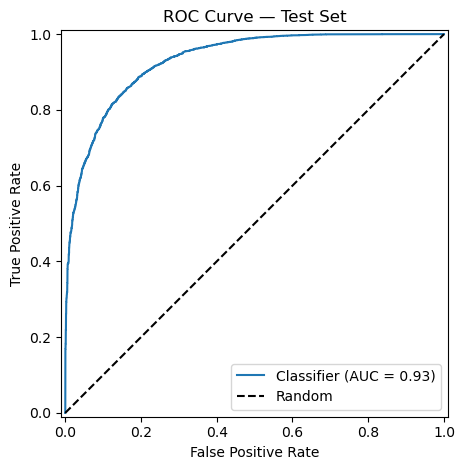

In [28]:
# ROC-AUC Performance Visualization
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.plot([0, 1], [0, 1],'k--', label='Random')
plt.title('ROC Curve — Test Set')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# Take first row as a template
booking = X.iloc[[0]].copy()

# Change the booking details
booking["no_of_adults"] = 2
booking["no_of_children"] = 1
booking["no_of_weekend_nights"] = 2
booking["no_of_week_nights"] = 3
booking["lead_time"] = 45
booking["avg_price_per_room"] = 110
booking["no_of_special_requests"] = 1

# Calculate new values
booking["total_nights"] = booking["no_of_weekend_nights"] + booking["no_of_week_nights"]
booking["total_guests"] = booking["no_of_adults"] + booking["no_of_children"]

# Preprocess and predict
p = model.predict(preprocessor.transform(booking), verbose=0)[0][0]

# Display result
print("Prediction:", "Canceled" if p >= 0.5 else "Not_Canceled")
print("Cancellation Probability:", round(p * 100, 2), "%")

Prediction: Canceled
Cancellation Probability: 97.17 %


In [63]:
import random

# check random test samples
n_samples = 10
sample_indices = random.sample(range(len(X_test)), n_samples)

correct = 0
for idx in sample_indices:
    # Make  prediction
    prob = model.predict(X_test[idx:idx + 1], verbose=0).ravel()[0]
    # convert probabiltiy to class
    pred_class = int(prob >= 0.5)
    # Get labels
    pred_label = le.inverse_transform([pred_class])[0]
    actual_label = le.inverse_transform([y_test[idx]])[0]

    # Check result
    if prediction == y_test[i]:
        correct += 1
        result = "Correct"
    else:
        result = "Wrong"
        
    print(f" Predicted: {pred_label:<13} | Actual: {actual_label:<13} | "f"Prob: {prob:.3f} | {result}")

print(f"\n{correct}/{n_samples} correct on this manual spot-check")

 Predicted: Canceled      | Actual: Canceled      | Prob: 0.229 | Correct
 Predicted: Canceled      | Actual: Canceled      | Prob: 0.055 | Correct
 Predicted: Canceled      | Actual: Not_Canceled  | Prob: 0.216 | Correct
 Predicted: Not_Canceled  | Actual: Not_Canceled  | Prob: 0.932 | Correct
 Predicted: Not_Canceled  | Actual: Canceled      | Prob: 0.941 | Correct
 Predicted: Not_Canceled  | Actual: Not_Canceled  | Prob: 0.929 | Correct
 Predicted: Not_Canceled  | Actual: Canceled      | Prob: 0.718 | Correct
 Predicted: Canceled      | Actual: Canceled      | Prob: 0.040 | Correct
 Predicted: Canceled      | Actual: Not_Canceled  | Prob: 0.478 | Correct
 Predicted: Not_Canceled  | Actual: Not_Canceled  | Prob: 0.832 | Correct

10/10 correct on this manual spot-check
